In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/zalando-research/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_test.csv
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_train.csv
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/train-images-idx3-ubyte


Using device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 40.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.12MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.92MB/s]


Training started...
Epoch 1 | Step 0 | Loss: 1.0430
Epoch 1 | Step 200 | Loss: 0.1905
Epoch 1 | Step 400 | Loss: 0.1302
Epoch 1 | Step 600 | Loss: 0.1305
Epoch 1 | Step 800 | Loss: 0.1049
Epoch 2 | Step 0 | Loss: 0.1205
Epoch 2 | Step 200 | Loss: 0.1220
Epoch 2 | Step 400 | Loss: 0.0942
Epoch 2 | Step 600 | Loss: 0.1086
Epoch 2 | Step 800 | Loss: 0.1074
Epoch 3 | Step 0 | Loss: 0.1159
Epoch 3 | Step 200 | Loss: 0.0989
Epoch 3 | Step 400 | Loss: 0.0946
Epoch 3 | Step 600 | Loss: 0.0988
Epoch 3 | Step 800 | Loss: 0.1066
Epoch 4 | Step 0 | Loss: 0.0971
Epoch 4 | Step 200 | Loss: 0.1064
Epoch 4 | Step 400 | Loss: 0.0952
Epoch 4 | Step 600 | Loss: 0.0916
Epoch 4 | Step 800 | Loss: 0.1010
Epoch 5 | Step 0 | Loss: 0.0927
Epoch 5 | Step 200 | Loss: 0.0894
Epoch 5 | Step 400 | Loss: 0.0845
Epoch 5 | Step 600 | Loss: 0.0977
Epoch 5 | Step 800 | Loss: 0.0808
Epoch 6 | Step 0 | Loss: 0.0973
Epoch 6 | Step 200 | Loss: 0.1131
Epoch 6 | Step 400 | Loss: 0.0921
Epoch 6 | Step 600 | Loss: 0.0899
Epoch 

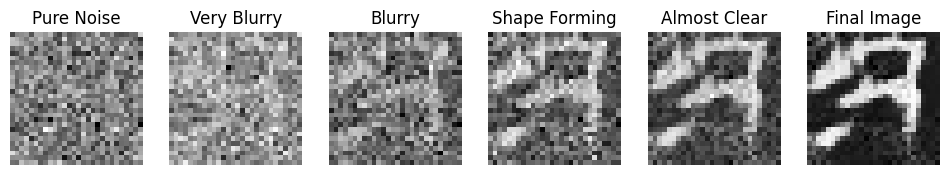

In [2]:
# ================================
# 1. Imports
# ================================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# ================================
# 2. Config
# ================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 64
EPOCHS = 10
LR = 1e-3
TIMESTEPS = 200

print("Using device:", DEVICE)

# ================================
# 3. Dataset (MNIST)
# ================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # important for good results
])

dataset = datasets.MNIST(
    root="/kaggle/working",
    train=True,
    download=True,
    transform=transform
)

loader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# ================================
# 4. Diffusion Schedule
# ================================
beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, TIMESTEPS).to(DEVICE)
alphas = 1. - betas
alpha_hat = torch.cumprod(alphas, dim=0)

# ================================
# 5. Simple Model (CNN)
# ================================
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 1, 3, padding=1)
        )

    def forward(self, x, t):
        # (t ignored for simplicity)
        return self.net(x)

model = SimpleCNN().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.MSELoss()

# ================================
# 6. Add Noise (Forward Diffusion)
# ================================
def add_noise(x, t):
    noise = torch.randn_like(x)

    sqrt_alpha_hat = torch.sqrt(alpha_hat[t])[:, None, None, None]
    sqrt_one_minus_alpha_hat = torch.sqrt(1 - alpha_hat[t])[:, None, None, None]

    noisy_x = sqrt_alpha_hat * x + sqrt_one_minus_alpha_hat * noise
    return noisy_x, noise

# ================================
# 7. Training
# ================================
print("Training started...")

for epoch in range(EPOCHS):
    for i, (images, _) in enumerate(loader):

        images = images.to(DEVICE)

        t = torch.randint(0, TIMESTEPS, (images.size(0),)).to(DEVICE)

        noisy_images, noise = add_noise(images, t)

        predicted_noise = model(noisy_images, t)

        loss = loss_fn(predicted_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if i % 200 == 0:
            print(f"Epoch {epoch+1} | Step {i} | Loss: {loss.item():.4f}")

print("Training finished!")

# ================================
# 8. Sampling with Steps (Blur → Clear)
# ================================
def sample_with_steps(model):
    model.eval()

    x = torch.randn((1, 1, 28, 28)).to(DEVICE)

    # timesteps where we capture output
    save_steps = [199, 150, 100, 50, 20, 0]
    saved_images = []

    with torch.no_grad():
        for t in reversed(range(TIMESTEPS)):

            t_tensor = torch.tensor([t]).to(DEVICE)

            predicted_noise = model(x, t_tensor)

            alpha = alphas[t]
            alpha_hat_t = alpha_hat[t]
            beta = betas[t]

            if t > 0:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)

            # reverse diffusion equation
            x = (1 / torch.sqrt(alpha)) * (
                x - ((1 - alpha) / torch.sqrt(1 - alpha_hat_t)) * predicted_noise
            ) + torch.sqrt(beta) * noise

            if t in save_steps:
                saved_images.append(x.cpu())

    model.train()
    return saved_images

# ================================
# 9. Plot Blur → Clear Progression
# ================================
images = sample_with_steps(model)

titles = [
    "Pure Noise",
    "Very Blurry",
    "Blurry",
    "Shape Forming",
    "Almost Clear",
    "Final Image"
]

plt.figure(figsize=(12, 3))

for i in range(len(images)):
    plt.subplot(1, len(images), i+1)
    plt.imshow(images[i][0][0], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.show()